# CNN robustness to additive noise

A trainable tensor generates a synthetic image-classification dataset. The target learner contains two convolutions, one pooling layer, and a position-sensitive linear head. Meta-training uses clean images; Gaussian noise is added only during the independent post-hoc evaluation.

In [13]:
from functools import partial

import torch

from cnn import LearnableImageDataset, TwoConvClassifier, make_two_conv_classifier
from evaluation import evaluate_noise_robustness, print_noise_audit
from meta_learning import MetaLearner
from meta_loss_functions import (
    cross_entropy_loss,
    pairwise_class_cross_entropy,
    variance_floor,
    intra_class_diversity,
)
from visualization import plot_image_dataset, plot_meta_history, plot_noise_robustness

## Configuration

In [50]:
# Dataset
SEED = 42
NUM_CLASSES = 4
SAMPLES_PER_CLASS = 20
IMAGE_SIZE = 16
CHANNELS = 1

# CNN
FIRST_CONV_CHANNELS = 8
SECOND_CONV_CHANNELS = 16
POOL_TYPE = "max"

# Inner learning
INNER_LR = 0.1
INNER_STEPS = 7
LEARNERS_PER_STEP = 2
TRAIN_FRACTION = 0.75

# Meta-optimization
META_STEPS = 3500
META_LR = 5e-3

# Collapse prevention
DIVERSITY_WEIGHT = 1

# Noise audit
NOISE_LEVELS = [0.00, 0.01, 0.03, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00, 1.10, 1.20, 1.30, 1.40, 1.50, 1.60, 1.70, 1.80, 1.90, 2.00]
AUDIT_TRIALS = 30
NOISE_SAMPLES_PER_TRIAL = 20

torch.manual_seed(SEED)

## Meta-training on clean images

In [43]:
generator = LearnableImageDataset(
    num_classes=NUM_CLASSES,
    samples_per_class=SAMPLES_PER_CLASS,
    image_size=IMAGE_SIZE,
    channels=CHANNELS,
)

cnn_factory = partial(
    make_two_conv_classifier,
    image_size=IMAGE_SIZE,
    channels=CHANNELS,
    first_channels=FIRST_CONV_CHANNELS,
    second_channels=SECOND_CONV_CHANNELS,
    pool_type=POOL_TYPE,
)

meta_learner = MetaLearner(
    generator=generator,
    learner_factory=cnn_factory,
    inner_loss_fn=cross_entropy_loss,
    meta_loss_fn=partial(
        cross_entropy_loss,
    ),
    regularization_fn=partial(
        intra_class_diversity,
        weight=DIVERSITY_WEIGHT,
    ),
    num_classes=NUM_CLASSES,
    meta_lr=META_LR,
    inner_lr=INNER_LR,
    inner_steps=INNER_STEPS,
    learners_per_step=LEARNERS_PER_STEP,
    train_fraction=TRAIN_FRACTION,
    first_order=False,
    seed=SEED,
)

step=0001 loss=1.2205 accuracy=0.350
step=0100 loss=1.1367 accuracy=0.325
step=0200 loss=1.0692 accuracy=0.200
step=0300 loss=1.0109 accuracy=0.225
step=0400 loss=0.9639 accuracy=0.175
step=0500 loss=0.9237 accuracy=0.200
step=0600 loss=0.8910 accuracy=0.225
step=0700 loss=0.8617 accuracy=0.225
step=0800 loss=0.8320 accuracy=0.425
step=0900 loss=0.8028 accuracy=0.500
step=1000 loss=0.7909 accuracy=0.450
step=1100 loss=0.7826 accuracy=0.425
step=1200 loss=0.7297 accuracy=0.800
step=1300 loss=0.7042 accuracy=0.825
step=1400 loss=0.6931 accuracy=0.600
step=1500 loss=0.5805 accuracy=0.875
step=1600 loss=0.4640 accuracy=0.975
step=1700 loss=0.6961 accuracy=0.925
step=1800 loss=0.3678 accuracy=1.000
step=1900 loss=0.0999 accuracy=1.000
step=2000 loss=0.3871 accuracy=0.750
step=2100 loss=0.5675 accuracy=1.000
step=2200 loss=0.4399 accuracy=1.000
step=2300 loss=0.4504 accuracy=1.000
step=2400 loss=0.5928 accuracy=1.000
step=2500 loss=0.0330 accuracy=1.000
step=2600 loss=-0.0421 accuracy=1.000


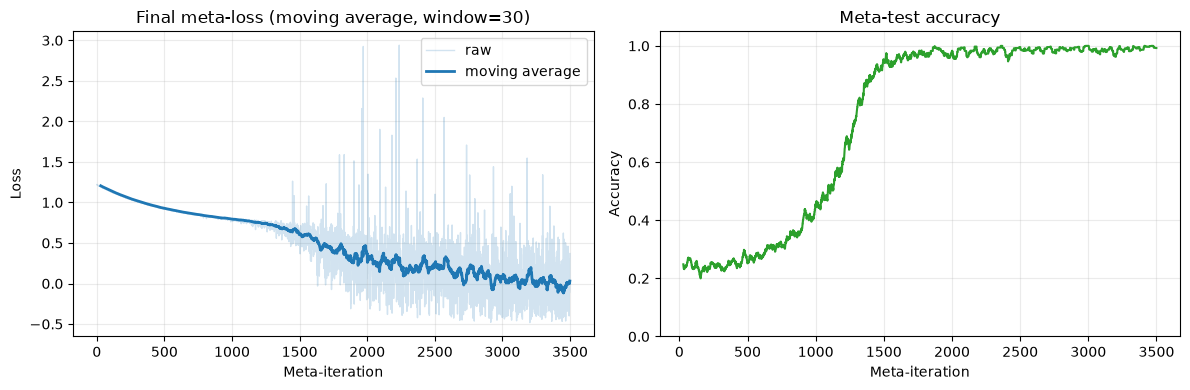

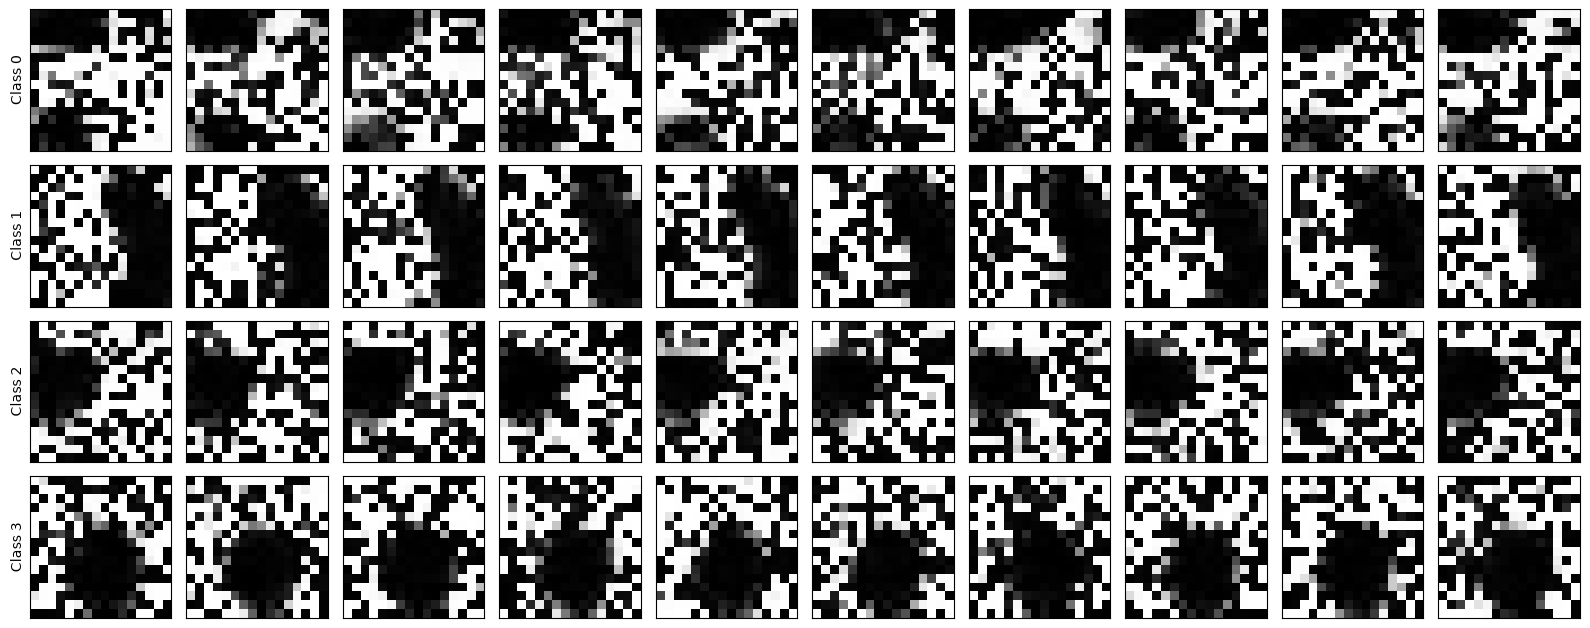

In [44]:
history = meta_learner.train(steps=META_STEPS, log_every=100)
x_frozen, y_frozen = meta_learner.frozen_dataset()

plot_meta_history(history, smoothing_window=30);
plot_image_dataset(x_frozen, y_frozen, samples_per_class=10);

## Independent noise audit

Every fresh CNN is trained on clean data using the same SGD learning rate and number of steps as the inner loop. Accuracy, prediction flip rate, and the mean L1 change in class probabilities are averaged over new train/test splits and noise samples.

sigma=0.000
  accuracy: 0.9833 +- 0.0898
  flip_rate: 0.0000 +- 0.0000
  probability_shift: 0.0000 +- 0.0000
sigma=0.010
  accuracy: 0.9837 +- 0.0880
  flip_rate: 0.0003 +- 0.0018
  probability_shift: 0.0023 +- 0.0008
sigma=0.030
  accuracy: 0.9833 +- 0.0898
  flip_rate: 0.0002 +- 0.0009
  probability_shift: 0.0103 +- 0.0039
sigma=0.050
  accuracy: 0.9828 +- 0.0924
  flip_rate: 0.0008 +- 0.0045
  probability_shift: 0.0195 +- 0.0075
sigma=0.100
  accuracy: 0.9783 +- 0.1139
  flip_rate: 0.0050 +- 0.0243
  probability_shift: 0.0454 +- 0.0176
sigma=0.200
  accuracy: 0.9742 +- 0.1263
  flip_rate: 0.0092 +- 0.0382
  probability_shift: 0.1061 +- 0.0429
sigma=0.300
  accuracy: 0.9705 +- 0.1351
  flip_rate: 0.0128 +- 0.0497
  probability_shift: 0.1734 +- 0.0727
sigma=0.400
  accuracy: 0.9667 +- 0.1394
  flip_rate: 0.0167 +- 0.0607
  probability_shift: 0.2431 +- 0.1063
sigma=0.500
  accuracy: 0.9594 +- 0.1498
  flip_rate: 0.0239 +- 0.0833
  probability_shift: 0.3085 +- 0.1405
sigma=0.600
  accur

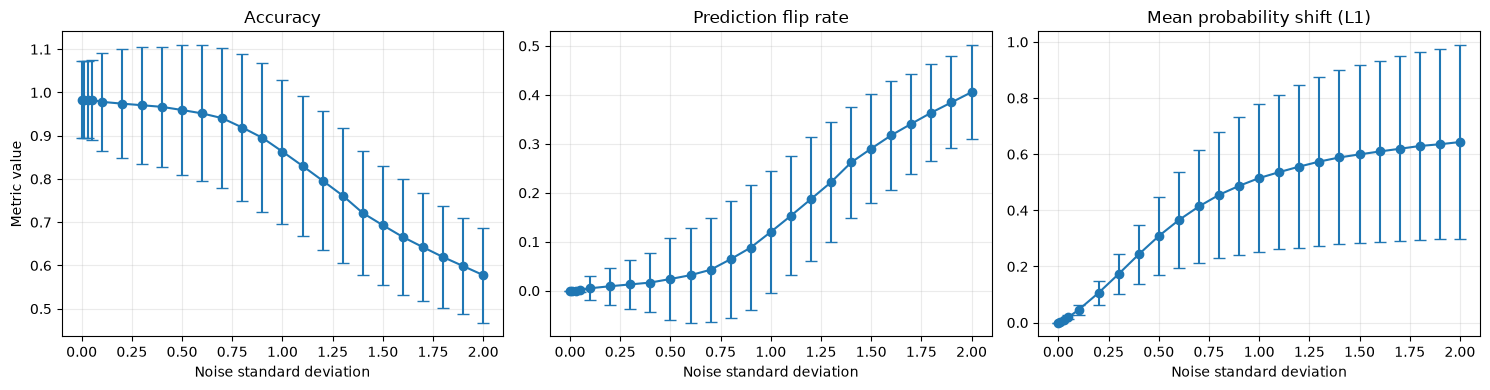

In [51]:
noise_summary = evaluate_noise_robustness(
    TwoConvClassifier,
    {
        "image_size": IMAGE_SIZE,
        "channels": CHANNELS,
        "first_channels": FIRST_CONV_CHANNELS,
        "second_channels": SECOND_CONV_CHANNELS,
        "pool_type": POOL_TYPE,
    },
    x_frozen,
    y_frozen,
    num_classes=NUM_CLASSES,
    noise_levels=NOISE_LEVELS,
    trials=AUDIT_TRIALS,
    noise_samples_per_trial=NOISE_SAMPLES_PER_TRIAL,
    train_fraction=TRAIN_FRACTION,
    training_steps=INNER_STEPS,
    learning_rate=INNER_LR,
    seed=10_000,
)

print_noise_audit(noise_summary)
plot_noise_robustness(noise_summary);